Primeira idea de teste de potêncial é utilizar um potencial da forma:


$$
V(x)=
\begin{cases}
\dfrac{V_0}{b}x, & 0\leq x<b,\\[6pt]
-\dfrac{V_0}{a}(x-b)+V_0, & b\leq x<a+b,
\end{cases}
$$

com extensão periódica

$$
V(x+L)=V(x),
\qquad L=a+b.
$$

A série de Fourier do potencial pode ser escrita na forma geral

$$
V(x)=\frac{a_0}{2}
+\sum_{n=1}^{\infty}
\left[
a_n\cos(k_nx)
+b_n\sin(k_nx)
\right],
$$

onde

$$
k_n=\frac{2\pi n}{L}.
$$

Para o potencial de rampa, os coeficientes são

$$
a_0=V_0,
$$

$$
a_n=
-\frac{V_0L^2}{\pi^2ab\,n^2}
\sin^2\left(\frac{\pi bn}{L}\right),
$$

e

$$
b_n=
\frac{V_0L^2}{2\pi^2ab\,n^2}
\sin\left(\frac{2\pi bn}{L}\right).
$$

Assim, uma aproximação suave do potencial pode ser obtida truncando a série em um número finito de harmônicos $N$:

$$
V_N(x)=\frac{V_0}{2}
+\sum_{n=1}^{N}
\left[
a_n\cos\left(\frac{2\pi nx}{L}\right)
+b_n\sin\left(\frac{2\pi nx}{L}\right)
\right].
$$



A força associada ao potencial é definida por

$$
F(x)=-\frac{dV}{dx}.
$$

Para a série de Fourier, a força pode ser escrita na forma geral

$$
F_N(x)=
\sum_{n=1}^{N}
k_n
\left[
a_n\sin(k_nx)
-b_n\cos(k_nx)
\right],
$$

ou, explicitamente,

$$
F_N(x)=
\frac{2\pi}{L}
\sum_{n=1}^{N}
n
\left[
a_n\sin\left(\frac{2\pi nx}{L}\right)
-b_n\cos\left(\frac{2\pi nx}{L}\right)
\right].
$$

Como $N$ é finito, $V_N(x)$ e $F_N(x)$ são funções suaves e periódicas.

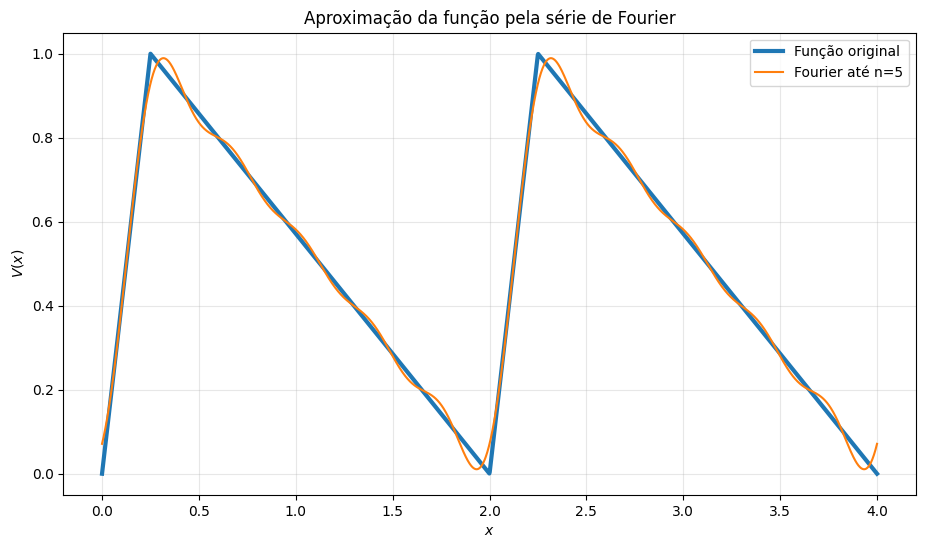

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# Parâmetros
# ==================================================

V0 = 1.0
a = 1.75
b = .25

L = a + b
k = 2 * np.pi / L

# Dois períodos
x = np.linspace(0, 2 * L, 2000)


# ==================================================
# Função original
# ==================================================

def V(x):
    x_mod = np.mod(x, L)

    return np.where(
        x_mod < b,
        V0 * x_mod / b,
        -V0 / a * (x_mod - b) + V0
    )


# ==================================================
# Coeficientes de Fourier
# ==================================================

a0 = V0


def an(n):
    return (
        -V0 * L**2
        / (np.pi**2 * a * b * n**2)
        * np.sin(np.pi * b * n / L)**2
    )


def bn(n):
    return (
        V0 * L**2
        / (2 * np.pi**2 * a * b * n**2)
        * np.sin(2 * np.pi * b * n / L)
    )


# ==================================================
# Série de Fourier
# ==================================================

def fourier(x, N):
    resultado = a0 / 2

    for n in range(1, N + 1):
        resultado += (
            an(n) * np.cos(2 * np.pi * n * x / L)
            + bn(n) * np.sin(2 * np.pi * n * x / L)
        )

    return resultado


# ==================================================
# Plot
# ==================================================

plt.figure(figsize=(11, 6))

# Função original
plt.plot(
    x,
    V(x),
    label="Função original",
    linewidth=3
)

# Aproximações
for N in [ 5]:
    plt.plot(
        x,
        fourier(x, N),
        linewidth=1.5,
        label=f"Fourier até n={N}"
    )

plt.xlabel("$x$")
plt.ylabel("$V(x)$")
plt.title("Aproximação da função pela série de Fourier")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

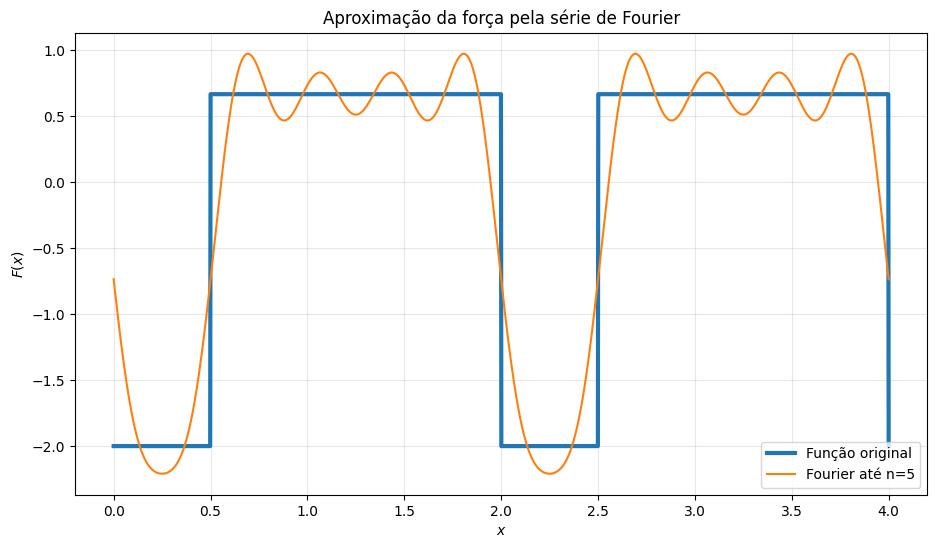

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# Parâmetros
# ==================================================

V0 = 1.0
a = 1.5
b = .5

L = a + b
k = 2 * np.pi / L

# Dois períodos
x = np.linspace(0, 2 * L, 2000)


# ==================================================
# Função original
# ==================================================

def F(x):
    x_mod = np.mod(x, L)

    return np.where(
        x_mod < b,
        -V0 / b,
        V0 / a
    )


# ==================================================
# Coeficientes de Fourier
# ==================================================

a0 = V0


def an(n):
    return (
        -V0 * L**2
        / (np.pi**2 * a * b * n**2)
        * np.sin(np.pi * b * n / L)**2
    )


def bn(n):
    return (
        V0 * L**2
        / (2 * np.pi**2 * a * b * n**2)
        * np.sin(2 * np.pi * b * n / L)
    )


# ==================================================
# Série de Fourier
# ==================================================

def fourier(x, N):
    resultado = 0

    for n in range(1, N + 1):
        kn = 2 * np.pi * n / L

        resultado += (
            kn * (
                an(n) * np.sin(kn * x)
                - bn(n) * np.cos(kn * x)
            )
        )

    return resultado


# ==================================================
# Plot
# ==================================================

plt.figure(figsize=(11, 6))

# Função original
plt.plot(
    x,
    F(x),
    label="Função original",
    linewidth=3
)

# Aproximações
for N in [5]:
    plt.plot(
        x,
        fourier(x, N),
        linewidth=1.5,
        label=f"Fourier até n={N}"
    )

plt.xlabel("$x$")
plt.ylabel("$F(x)$")
plt.title("Aproximação da força pela série de Fourier")

plt.grid(alpha=0.3)
plt.legend()

plt.show()